# **ArabicaQA Dataset + Statistics**

In [ ]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True
)

print(result.stdout)

aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.13.0
appdirs==1.4.4
asttokens==3.0.1
attrs==26.1.0
backoff==2.2.1
bcrypt==5.0.0
build==1.5.0
certifi==2026.4.22
charset-normalizer==3.4.7
chromadb==1.3.7
click==8.3.3
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
dataclasses-json==0.6.7
datasets==4.4.1
debugpy==1.8.20
decorator==5.2.1
dill==0.4.0
diskcache==5.6.3
distro==1.9.0
docstring_parser==0.18.0
durationpy==0.10
evaluate==0.4.6
executing==2.2.1
filelock==3.29.0
flatbuffers==25.12.19
fonttools==4.62.1
frozenlist==1.8.0
fsspec==2025.10.0
googleapis-common-protos==1.74.0
greenlet==3.5.0
grpcio==1.80.0
h11==0.16.0
hf-xet==1.4.3
httpcore==1.0.9
httptools==0.7.1
httpx==0.28.1
httpx-sse==0.4.3
huggingface-hub==0.36.0
idna==3.13
importlib_metadata==8.7.1
importlib_resources==7.1.0
instructor==1.15.1
ipykernel==7.2.0
ipython==9.13.0
ipython_pygments_lexers==1.1.1
jedi==0.20.0
Jinja2==3.1.6
jiter==0.13.0
joblib==1.5.3

In [ ]:
import json
from pathlib import Path
from typing import List, Dict
import pandas as pd

BASE_DIR = Path("arabicaqa_rag_results/dataset")

# Optional: simple cleaner
def clean_text(text: str) -> str:
    if text is None:
        return ""
    return str(text).strip()

def flatten_qa_split(json_path: Path, split_name: str) -> pd.DataFrame:
    """
    Load one QA JSON file (MRC or Open-Domain with context)
    and flatten it into a DataFrame.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    records: List[Dict] = []

    for article in raw["data"]:
        for para in article["paragraphs"]:
            context = clean_text(para.get("context", ""))
            document_id = para.get("document_id")

            for qa in para["qas"]:
                question = clean_text(qa.get("question", ""))
                # base is_impossible flag (from file if present)
                is_impossible = bool(qa.get("is_impossible", False))

                answers_list = qa.get("answers", [])
                answer_texts = [clean_text(a.get("text", "")) for a in answers_list]

                # ---- NEW LOGIC: '.' = unanswerable ----
                # if the only answer is "." → treat as unanswerable
                has_only_dot = (
                    len(answer_texts) > 0
                    and all(ans == "." for ans in answer_texts)
                )

                if has_only_dot:
                    is_impossible = True
                    # Usually for unanswerable we keep answers empty
                    answer_texts = []

                # Also: if there are no answers at all, mark as impossible
                if len(answer_texts) == 0:
                    is_impossible = True

                records.append(
                    {
                        "split": split_name,       # train / validation / test
                        "document_id": document_id,
                        "question_id": qa.get("id"),
                        "question": question,
                        "context": context,
                        "answers": answer_texts,   # list of strings
                        "is_impossible": is_impossible,
                    }
                )

    return pd.DataFrame(records)

# ---- Build all three MRC splits ----
df_train_mrc = flatten_qa_split(BASE_DIR / "MRC" / "train.json", "train")
df_val_mrc   = flatten_qa_split(BASE_DIR / "MRC" / "validation.json", "validation")
df_test_mrc  = flatten_qa_split(BASE_DIR / "MRC" / "test.json", "test")

# (Optional) If Open-Domain uses the same structure & has context now:
# df_train_open = flatten_qa_split(BASE_DIR / "Open-Domain" / "train.json", "train")
# df_val_open   = flatten_qa_split(BASE_DIR / "Open-Domain" / "validation.json", "validation")
# df_test_open  = flatten_qa_split(BASE_DIR / "Open-Domain" / "test.json", "test")

# ---- Merge MRC into one DataFrame ----
df_all_mrc = pd.concat([df_train_mrc, df_val_mrc, df_test_mrc], ignore_index=True)

df_all_mrc.head()


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1338857,645198,ما هو عدد المقاطعات في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[15],False
1,train,1338857,645409,ما هي أكبر طائفة مسيحية في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[الكنيسة الإنجيلية اللوثرية الإستونية],False
2,train,1338857,645410,كم عدد المسلمين في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[المسلمين يتجاوز عددهم 10000],False
3,train,1338857,645203,ما هو عدد سكان إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,"[1,319,133مليون نسمة]",False
4,train,1338857,645202,ما هي عاصمة إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[تالين],False


In [ ]:
from pathlib import Path
import pandas as pd
import json

BASE_DIR = Path("arabicaqa_rag_results/dataset")
BASE_DIR.mkdir(parents=True, exist_ok=True)

df_export = df_all_mrc.copy()

list_columns = ["answers"] 

for col in list_columns:
    df_export[col] = df_export[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else "[]"
    )

df_export.to_csv(BASE_DIR / "df_all_mrc.csv", index=False, encoding="utf-8-sig")

print("✅ df_all_mrc.csv saved")


✅ df_all_mrc.csv saved


In [ ]:
import pandas as pd
import json

df_all_mrc = pd.read_csv("arabicaqa_rag_results/dataset/df_all_mrc.csv")

list_columns = ["answers"]

for col in list_columns:
    df_all_mrc[col] = df_all_mrc[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])


| **Category**            | **Training** | **Validation** | **Test** | **Total**  |
| ----------------------- | ------------ | -------------- | -------- | ---------- |
|<mark> **MRC (with answers)**  | 62,186       | 13,483         | 13,426   | **89,095**|
|<mark> **MRC (unanswerable)**  | 2,596        | 561            | 544      | **3,701**  |
| **Open-Domain**         | 62,057       | 13,475         | 13,414   | **88,946** |
| **Open-Domain (Human)** | 58,676       | 12,715         | 12,592   | **83,983** |

We will take a sample of **MRC (with answers)** and **MRC (unanswerable)** => 500 form each part => Total 1000

In [ ]:
df_all_mrc["is_impossible"].value_counts()

is_impossible
False    89095
True      3701
Name: count, dtype: int64

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ============= 1) Helper functions =============

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).split())

latin_pattern = re.compile(r"[A-Za-z]")

def foreign_word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    tokens = str(text).split()
    return sum(1 for t in tokens if latin_pattern.search(t))


# ============= 2) Compute statistics =============

# Lengths
df_all_mrc["context_word_len"] = df_all_mrc["context"].apply(word_count)
df_all_mrc["question_word_len"] = df_all_mrc["question"].apply(word_count)

# Number of answers
def answers_len_safe(x):
    if isinstance(x, list):
        return len(x)
    return 0

df_all_mrc["n_answers"] = df_all_mrc["answers"].apply(answers_len_safe)

# Answer lengths (flatten all answers)
all_answer_lengths = []
for ans_list in df_all_mrc["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_answer_lengths.append(word_count(a))

mean_answer_len = float(np.mean(all_answer_lengths)) if all_answer_lengths else 0.0

# Foreign words in context
df_all_mrc["context_foreign_word_count"] = df_all_mrc["context"].apply(
    foreign_word_count
)

# Means
mean_context_len = df_all_mrc["context_word_len"].mean()
mean_question_len = df_all_mrc["question_word_len"].mean()
mean_n_answers = df_all_mrc["n_answers"].mean()
mean_foreign_per_context = df_all_mrc["context_foreign_word_count"].mean()

print("📊 Dataset stats (MRC):")
print(f"- Mean context length (words):        {mean_context_len:.2f}")
print(f"- Mean question length (words):       {mean_question_len:.2f}")
print(f"- Mean #answers per question:         {mean_n_answers:.2f}")
print(f"- Mean answer length (words, global): {mean_answer_len:.2f}")
print(f"- Mean foreign words per context:     {mean_foreign_per_context:.2f}")

📊 Dataset stats (MRC):
- Mean context length (words):        456.87
- Mean question length (words):       7.71
- Mean #answers per question:         0.96
- Mean answer length (words, global): 8.83
- Mean foreign words per context:     2.20


Saved → arabicaqa_rag_results/ragas_full\figures_full\full_means_bar.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_means_bar.pdf


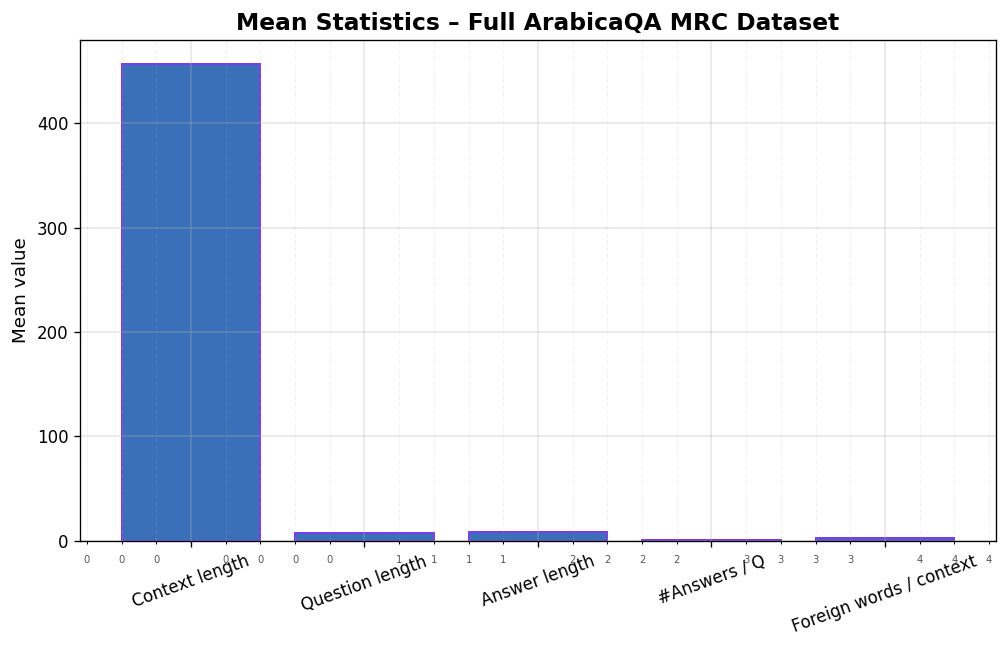

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_context_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_context_length.pdf


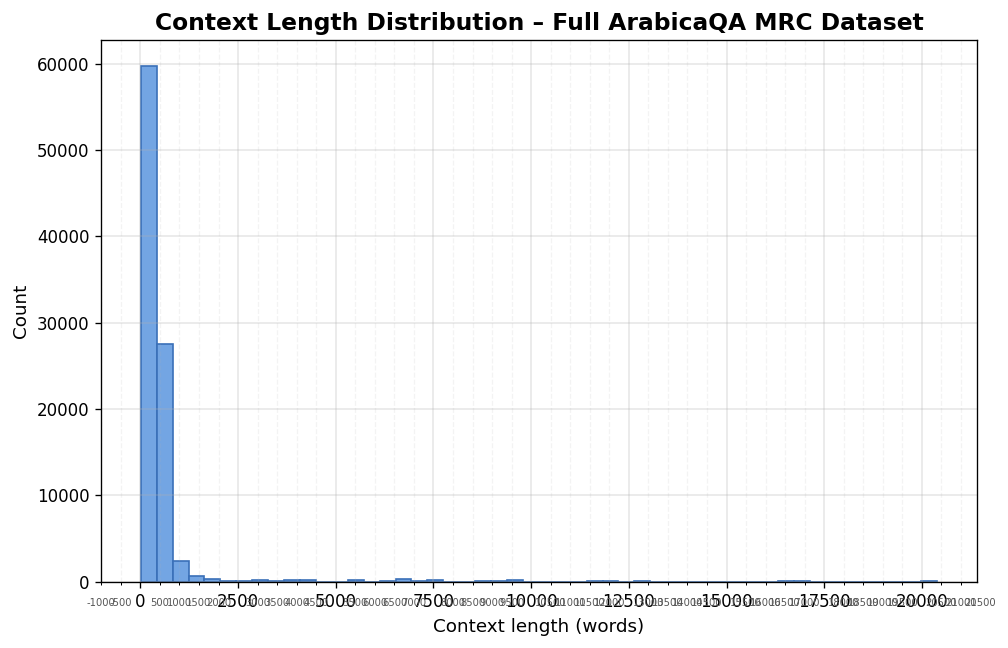

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_question_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_question_length.pdf


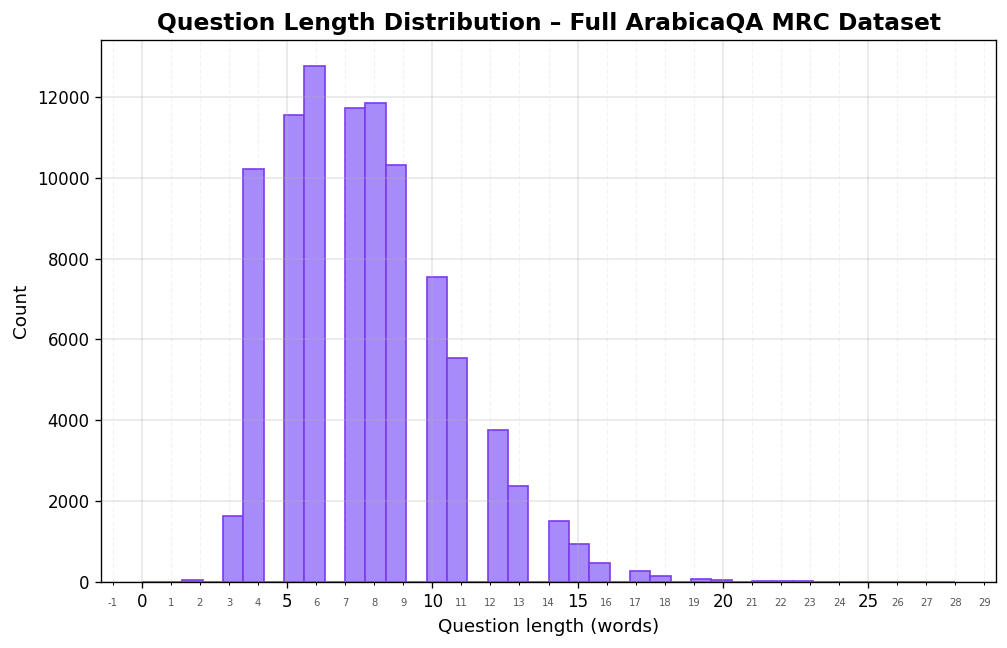

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_answer_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_answer_length.pdf


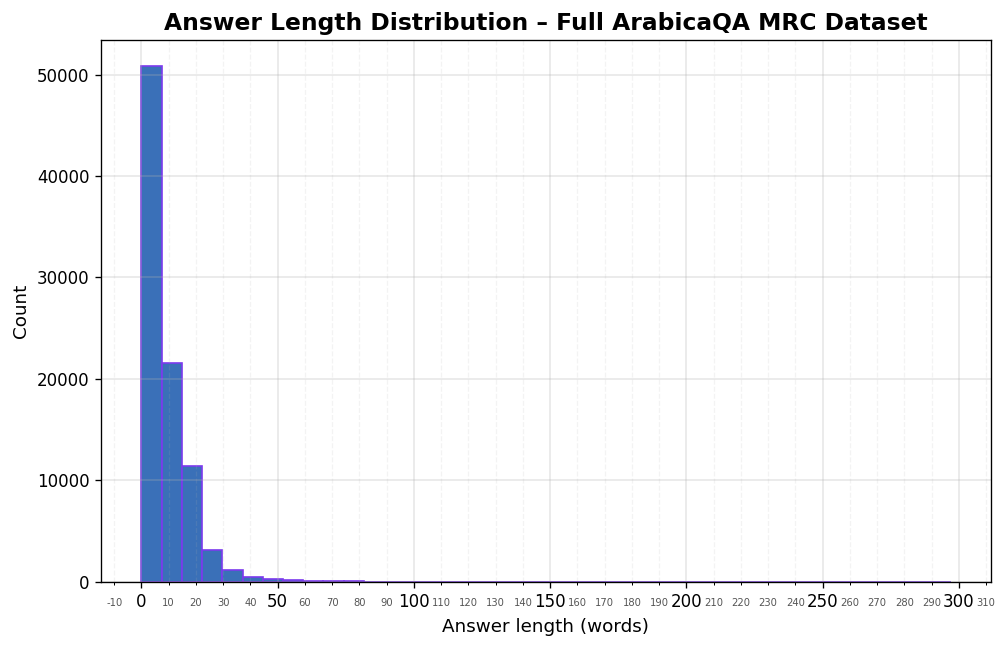

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_foreign_words.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_foreign_words.pdf


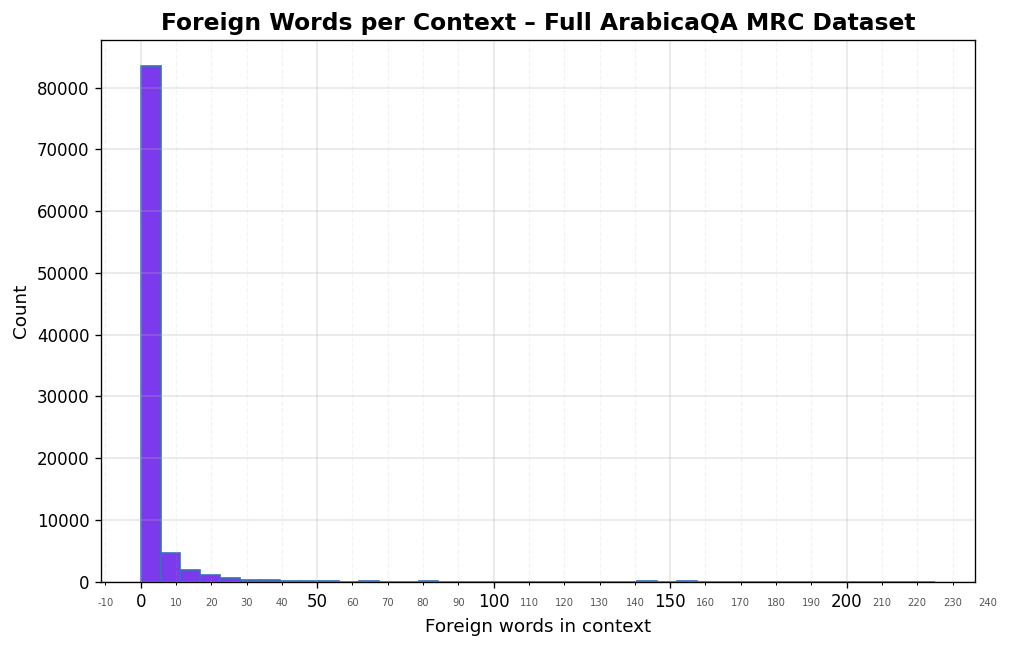

In [ ]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_full")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# THEME
# ======================
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 120

def apply_style_with_minor_ticks(ax):
    """Apply theme + grid + minor ticks labels"""
    ax.grid(which="major", alpha=0.3, linewidth=1)
    ax.grid(which="minor", alpha=0.15, linestyle="--")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    minor_ticks = ax.xaxis.get_minorticklocs()
    for tick in minor_ticks:
        ax.text(
            tick,
            -0.045,
            f"{int(tick)}",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color="#555",
            ha="center"
        )

    plt.tight_layout()

def save_fig(name_base: str):
    """Save current figure as PNG + PDF."""
    png_path = os.path.join(FIG_DIR, f"{name_base}.png")
    pdf_path = os.path.join(FIG_DIR, f"{name_base}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("Saved →", png_path)
    print("Saved →", pdf_path)


# ======================================================
# 3) Bar plot of the means
# ======================================================
labels = [
    "Context length",
    "Question length",
    "Answer length",
    "#Answers / Q",
    "Foreign words / context",
]

values = [
    mean_context_len,
    mean_question_len,
    mean_answer_len,
    mean_n_answers,
    mean_foreign_per_context,
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(labels, values, color=PRIMARY, edgecolor=ACCENT2, linewidth=1.2)
ax.set_ylabel("Mean value")
ax.set_title("Mean Statistics – Full ArabicaQA MRC Dataset", fontsize=14)
ax.tick_params(axis="x", rotation=20)
apply_style_with_minor_ticks(ax)

save_fig("full_means_bar")
plt.show()


# ======================================================
# 4) Histograms for FULL DATA
# ======================================================

# ========= Context length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["context_word_len"], bins=50, color=SECONDARY, edgecolor=PRIMARY)
ax.set_xlabel("Context length (words)")
ax.set_ylabel("Count")
ax.set_title("Context Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_context_length")
plt.show()


# ========= Question length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["question_word_len"], bins=40, color=ACCENT1, edgecolor=ACCENT2)
ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Question Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_question_length")
plt.show()


# ========= Answer length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(all_answer_lengths, bins=40, color=PRIMARY, edgecolor=ACCENT2)
ax.set_xlabel("Answer length (words)")
ax.set_ylabel("Count")
ax.set_title("Answer Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_answer_length")
plt.show()


# ========= Foreign words per context =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["context_foreign_word_count"], bins=40, color=ACCENT2, edgecolor=PRIMARY)
ax.set_xlabel("Foreign words in context")
ax.set_ylabel("Count")
ax.set_title("Foreign Words per Context – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_foreign_words")
plt.show()


In [ ]:
import json
from pathlib import Path
from typing import List, Dict
import pandas as pd

BASE_DIR = Path("arabicaqa_rag_results/dataset")

# Optional: simple cleaner
def clean_text(text: str) -> str:
    if text is None:
        return ""
    return str(text).strip()

def flatten_qa_split(json_path: Path, split_name: str) -> pd.DataFrame:
    """
    Load one QA JSON file (MRC or Open-Domain with context)
    and flatten it into a DataFrame.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    records: List[Dict] = []

    for article in raw["data"]:
        for para in article["paragraphs"]:
            context = clean_text(para.get("context", ""))
            document_id = para.get("document_id")

            for qa in para["qas"]:
                question = clean_text(qa.get("question", ""))
                # base is_impossible flag (from file if present)
                is_impossible = bool(qa.get("is_impossible", False))

                answers_list = qa.get("answers", [])
                answer_texts = [clean_text(a.get("text", "")) for a in answers_list]

                # ---- NEW LOGIC: '.' = unanswerable ----
                # if the only answer is "." → treat as unanswerable
                has_only_dot = (
                    len(answer_texts) > 0
                    and all(ans == "." for ans in answer_texts)
                )

                if has_only_dot:
                    is_impossible = True
                    # Usually for unanswerable we keep answers empty
                    answer_texts = []

                # Also: if there are no answers at all, mark as impossible
                if len(answer_texts) == 0:
                    is_impossible = True

                records.append(
                    {
                        "split": split_name,       # train / validation / test
                        "document_id": document_id,
                        "question_id": qa.get("id"),
                        "question": question,
                        "context": context,
                        "answers": answer_texts,   # list of strings
                        "is_impossible": is_impossible,
                    }
                )

    return pd.DataFrame(records)

# ---- Build all three MRC splits ----
df_train_mrc = flatten_qa_split(BASE_DIR / "MRC" / "train.json", "train")
df_val_mrc   = flatten_qa_split(BASE_DIR / "MRC" / "validation.json", "validation")
df_test_mrc  = flatten_qa_split(BASE_DIR / "MRC" / "test.json", "test")

# (Optional) If Open-Domain uses the same structure & has context now:
# df_train_open = flatten_qa_split(BASE_DIR / "Open-Domain" / "train.json", "train")
# df_val_open   = flatten_qa_split(BASE_DIR / "Open-Domain" / "validation.json", "validation")
# df_test_open  = flatten_qa_split(BASE_DIR / "Open-Domain" / "test.json", "test")

# ---- Merge MRC into one DataFrame ----
df_all_mrc = pd.concat([df_train_mrc, df_val_mrc, df_test_mrc], ignore_index=True)



In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
from tqdm import tqdm
from collections import Counter

import os

ner_results_path = "arabicaqa_rag_results/dataset/full_arabicaQA_MRC_dataset_ner_counts.csv"

os.makedirs(os.path.dirname(ner_results_path), exist_ok=True)

model_id = "CAMeL-Lab/bert-base-arabic-camelbert-msa-ner"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForTokenClassification.from_pretrained(model_id)

ner = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

def get_entity_counts(texts, max_tokens=512):
    entity_counter = Counter()
    for t in tqdm(texts):
        if not isinstance(t, str) or not t.strip():
            continue

        enc = tokenizer(
            t,
            truncation=True,
            max_length=max_tokens,
            return_tensors=None
        )
       
        input_ids = enc["input_ids"]
       
        if isinstance(input_ids[0], int):
            truncated_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        else:
            truncated_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)

        ents = ner(truncated_text)
        for e in ents:
            entity_counter[e["entity_group"]] += 1

    return entity_counter


# ==============================
# Full ArabicaQA MRC Dataset entities (ACTIVE)
# ==============================
df_all_mrc_contexts = df_all_mrc["context"].dropna().tolist()

df_all_mrc_entity_counts = get_entity_counts(df_all_mrc_contexts)

print("\n=== Full ArabicaQA MRC Dataset NER STATISTICS ===")
for k, v in df_all_mrc_entity_counts.items():
    print(f"{k}: {v}")

df_all_mrc_ner = pd.DataFrame({
    "entity_type": list(df_all_mrc_entity_counts.keys()),
    "sample": list(df_all_mrc_entity_counts.values()),
})

df_all_mrc_ner.to_csv(ner_results_path, index=False, encoding="utf-8-sig")

print(f"Saved NER results to: {ner_results_path}")
print(df_all_mrc_ner.head())



c:\Users\Zohoor Almalki\Projects\NLP\arabic-ner-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20646.26it/s]
[transformers] BertForTokenClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa-ner
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  1%|          | 669/92796 [08:26<19:21:46,  1.32it/s]


KeyboardInterrupt: 

In [ ]:
import os
import matplotlib.pyplot as plt

# ====== Theme colors ======
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

colors = [PRIMARY, SECONDARY, ACCENT1, ACCENT2, "#4FB6A0", "#F2A93B", "#D96459"]

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# PREPARE DATA
# ======================
df_plot = df_all_mrc_ner.sort_values("sample", ascending=False)

labels = df_plot["entity_type"].astype(str).tolist()
sizes  = df_plot["sample"].astype(float).tolist()

total_entities = int(sum(sizes))

# ======================
# PIE CHART
# ======================
fig, ax = plt.subplots(figsize=(6.5, 5.5))

patches, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors[:len(labels)],
    startangle=140,
    textprops={"fontsize": 11}
)

# improve label style on wedges
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax.set_title("NER Entity Distribution — Full ArabicaQA MRC Dataset", fontsize=15, weight="bold")

# ========= Inset Box ==========
box_text = f"Total entities: {total_entities}\n"
for ent, count in zip(labels, sizes):
    box_text += f"{ent}: {int(count)}\n"

props = dict(boxstyle="round,pad=0.5", facecolor="#F0F4FF", edgecolor=PRIMARY)

ax.text(
    0.92, 0.05,                 # box position inside axes
    box_text,
    transform=ax.transAxes,
    fontsize=10.5,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=props
)

plt.tight_layout()

# ======================
# SAVE
# ======================
png_path = os.path.join(FIG_DIR, "full_arabicaqa_mrc_ner_entity_distribution_pie.png")
pdf_path = os.path.join(FIG_DIR, "full_arabicaqa_mrc_ner_entity_distribution_pie.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved → {png_path}")
print(f"Saved → {pdf_path}")
